# Lab 10

## Data Engineering

In [394]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, accuracy_score, ConfusionMatrixDisplay, classification_report

In [395]:
df = pd.read_csv("Life_Expectancy_Data.csv")
df.columns = df.columns.str.strip().str.lower().str.replace("  ", " ").str.replace(" ", "_").str.replace("-", "_")

In [396]:
df = df.drop(columns=["population", "gdp"])

In [397]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [398]:
df = df.drop_duplicates()

In [399]:
X = df.drop(columns=["life_expectancy"])
y = df["life_expectancy"]

In [400]:
X = pd.get_dummies(X, columns=["status"])

In [401]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [402]:
robust_cols = ['measles', 'percentage_expenditure', 'infant_deaths', 'under_five_deaths', 'hiv/aids']
robust_scaler = RobustScaler()
X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

In [403]:
standard_cols = [col for col in X_train.columns if col not in robust_cols + ['status']]
std_scaler = StandardScaler()
X_train[standard_cols] = std_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = std_scaler.transform(X_test[standard_cols])

## Regression

In [404]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [405]:
y_pred = model.predict(X_test)

In [406]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

In [407]:
print(f"Mean Square Error (MSE): {mse}")
print(f"Root Mean Square Error (RMSE): {rmse}")
print(f"R2 Score: {r2_lr}")

Mean Square Error (MSE): 15.363033695843574
Root Mean Square Error (RMSE): 3.9195706009515345
R2 Score: 0.8227356555517286


In [408]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [409]:
y_pred = model.predict(X_test)

In [410]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2_dt = r2_score(y_test, y_pred)

In [411]:
print(f"Mean Square Error (MSE): {mse}")
print(f"Root Mean Square Error (RMSE): {rmse}")
print(f"R2 Score: {r2_dt}")

Mean Square Error (MSE): 6.461394557823129
Root Mean Square Error (RMSE): 2.5419273313419346
R2 Score: 0.9254460484048783


In [412]:
if r2_lr > r2_dt:
  print("Linear Regression performs better")
else:
  print("Decision Tree Regression performs better")

Decision Tree Regression performs better


## Classification

In [413]:
X = df.drop(columns=["status"])
y = df["status"]

In [414]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [415]:
robust_cols = ['measles', 'percentage_expenditure', 'infant_deaths', 'under_five_deaths', 'hiv/aids']
robust_scaler = RobustScaler()
X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

In [416]:
standard_cols = [col for col in X_train.columns if col not in robust_cols + ['status']]
std_scaler = StandardScaler()
X_train[standard_cols] = std_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = std_scaler.transform(X_test[standard_cols])

In [417]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [418]:
y_pred = model.predict(X_test)

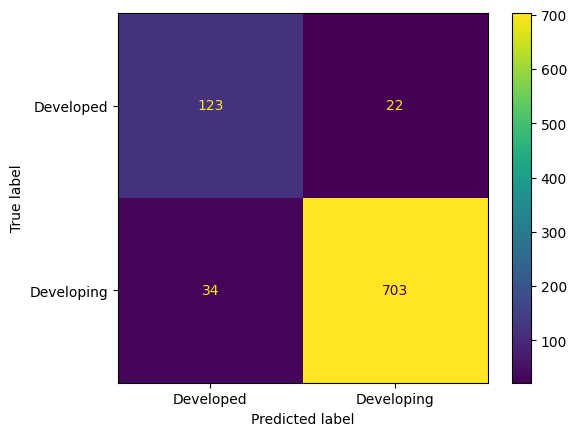

In [419]:
accuracy_score_lr = accuracy_score(y_test, y_pred)
confusion_matrix = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [420]:
print(f"Accuracy Score: {accuracy_score_lr}")
print(f"Classification Report:\n{report}")

Accuracy Score: 0.9365079365079365
Classification Report:
              precision    recall  f1-score   support

   Developed       0.78      0.85      0.81       145
  Developing       0.97      0.95      0.96       737

    accuracy                           0.94       882
   macro avg       0.88      0.90      0.89       882
weighted avg       0.94      0.94      0.94       882



In [421]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [422]:
y_pred = model.predict(X_test)

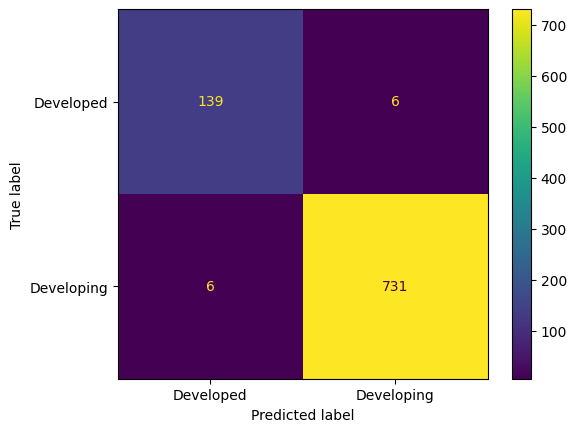

In [423]:
accuracy_score_rf = accuracy_score(y_test, y_pred)
confusion_matrix = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [424]:
print(f"Accuracy Score: {accuracy_score_rf}")
print(f"Classification Report:\n{report}")

Accuracy Score: 0.9863945578231292
Classification Report:
              precision    recall  f1-score   support

   Developed       0.96      0.96      0.96       145
  Developing       0.99      0.99      0.99       737

    accuracy                           0.99       882
   macro avg       0.98      0.98      0.98       882
weighted avg       0.99      0.99      0.99       882



In [425]:
if accuracy_score_lr > accuracy_score_rf:
  print("Logistic Regression performs better")
else:
  print("Random Forest Classifier performs better")

Random Forest Classifier performs better
